# Проект по эконометрике 

In [35]:
import pandas as pd
import numpy as np

In [36]:
df = pd.read_csv('data_process/all_data_final_llm.csv')
df = df.rename(columns={'index':'rang_id'})
df

,has_secondary_education,has_higher_education,work_experience,master_id,master_id.1,rang_id,docs_verified,gender,guarantee,rating,...,is_certified,price_socket,suitabilityHints,discount,insurance,contract,cur_score,profi_ru_start,album_count,photos_count
0,True,False,7.0,https://profi.ru/profile/AbdullinAA22/,https://profi.ru/profile/AbdullinAA22/,110.0,True,NaN,Нет гарантии,0,...,False,NaN,NaN,NaN,NaN,NaN,50.679233,На сервисе с июня 2025 г,0,0
1,True,False,8.0,https://profi.ru/profile/AbdullinAM9/,https://profi.ru/profile/AbdullinAM9/,158.0,True,MALE,Нет гарантии,0,...,False,NaN,NaN,NaN,NaN,NaN,50.700671,На сервисе с ноября 2024 г. (1 год),0,7
2,True,False,6.0,https://profi.ru/profile/AbdullinAN2/,https://profi.ru/profile/AbdullinAN2/,131.0,True,MALE,По договоренности,"4,73",...,False,NaN,Мало отзывов по вашей услуге,NaN,NaN,NaN,50.761180,На сервисе с октября 2020 г. (5 лет),0,2
3,False,True,NaN,https://profi.ru/profile/AbdullinLR/,https://profi.ru/profile/AbdullinLR/,39.0,True,MALE,Нет гарантии,"5,0",...,False,NaN,NaN,NaN,NaN,NaN,50.500441,NaN,0,0
4,True,False,7.0,https://profi.ru/profile/AbrashevYI/,https://profi.ru/profile/AbrashevYI/,85.0,True,MALE,Нет гарантии,0,...,False,NaN,NaN,NaN,NaN,NaN,50.782032,NaN,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
738,False,False,23.0,https://profi.ru/profile/ZinnurovDI2/,https://profi.ru/profile/ZinnurovDI2/,108.0,True,MALE,Нет гарантии,0,...,False,NaN,NaN,NaN,NaN,NaN,50.539320,NaN,2,3
739,True,False,1.0,https://profi.ru/profile/ZiyautdinovFZ/,https://profi.ru/profile/ZiyautdinovFZ/,95.0,True,MALE,Нет гарантии,0,...,False,NaN,NaN,NaN,NaN,NaN,50.787963,На сервисе с марта 2025 г. (1 год),0,0
740,True,False,7.0,https://profi.ru/profile/ZlobinAA22/,https://profi.ru/profile/ZlobinAA22/,48.0,True,MALE,Нет гарантии,0,...,False,NaN,NaN,NaN,NaN,NaN,50.798721,На сервисе с сентября 2025 г,0,0
741,True,False,10.0,https://profi.ru/profile/ZvitseviLA/,https://profi.ru/profile/ZvitseviLA/,76.0,True,MALE,Нет гарантии,"4,76",...,False,NaN,NaN,NaN,NaN,NaN,50.753450,NaN,0,0


In [37]:
df.isna().sum()

has_secondary_education     59
has_higher_education        59
work_experience            128
master_id                    0
master_id.1                  0
rang_id                      0
docs_verified                0
gender                      69
guarantee                    0
rating                       0
reviews_count                0
is_highly_praised            0
is_certified                 0
price_socket               646
suitabilityHints           610
discount                   650
insurance                  737
contract                   706
cur_score                    0
profi_ru_start             324
album_count                  0
photos_count                 0
dtype: int64

In [38]:
def guarantee_transform(value):
## переводим гарантию в числа в месяцах

    ## без гарантии
    if value in ['Нет гарантии', 'По договоренности', '«Штукатурка и изделия из ГКЛ, ГВЛ – 1 год»', '«Гарантия это надежность выполненных работ»']:
        return 0
    
    ## 1 год
    elif value in ['«1 год»', '«Гарантия на работы 1 год»', '«На 1 год»', '«Гарантия на выполненную работу 12 месяцев»',
                              '«В течении года при условии правильного пользования (если клиент не виноват в проблеме) + сервисное обслуживание на льготных условиях (по договоренности)»']:
        return 12
    
    ## 6 месяцев
    elif value in ['«6 месяцев»', '«От 6 месяцев до 1 года»', '«Гарантия 6 месяцев с окончания работ»']:
        return 6
    
    ## 2 года
    elif value in ['«2 года»', '«2 года, при условии подбора материалов мастером и соблюдении технологии работ»', '«Гарантия 2 года с техническим сопровождением»']:
        return 24
    
    ## 3 года
    elif value in ['«3 года»']:
        return 36
    
    ## 1 месяц
    elif value in ['«Гарантия на Услуги от 30 дней»', '«1 месяц»', 
                              '«В разумных пределах на то что от меня зависит. Можно прописывать в Договоре»', 
                              '«Даю гарантию на выполненную работу»', 'По договоренности', 
                              '«Работаем с договором »', '«От 14 до 400 дней»', 
                              '«Договор подряда, и гарантия на работы до 10 лет»']:
        return 1
    
    return None


months = {'января': 1, 'февраля': 2, 'марта': 3, 'апреля': 4, 'мая': 5, 'июня': 6, 'июля': 7, 'августа': 8, 'сентября': 9, 'октября': 10, 'ноября': 11, 'декабря': 12}
def profiru_start_transformer(value):
    month_count = None
    if pd.notna(value):
        list_val = value.split()
        month = list_val[3]
        year = int(list_val[4])
        month_count = 12 * (2026 - year) + (5 - months[month])
    
    return month_count


df['no_electric_reviews'] = None
df['few_electric_reviews'] = None

def suitabilityHints_transformer(row):
    if row['suitabilityHints'] == 'Нет отзывов по вашей услуге':
        row['no_electric_reviews'] = 1

    elif row['suitabilityHints'] == 'Мало отзывов по вашей услуге':
        row['few_electric_reviews'] = 1

    return row


df['guarantee'] = df['guarantee'].apply(guarantee_transform)
df['is_highly_praised'] = df['is_highly_praised'].apply(lambda x: 1 if x==True else 0)
df['is_certified'] = df['is_certified'].apply(lambda x: 1 if x==True else 0)

df['docs_verified'] = df['docs_verified'].apply(lambda x: 1 if x==True else 0)
df.drop(columns=['gender'], inplace=True)

df['has_secondary_education'] = df['has_secondary_education'].apply(lambda x: 1 if x==True else 0)
df['has_higher_education'] = df['has_higher_education'].apply(lambda x: 1 if x==True else 0)

df.drop(columns=['master_id.1'], inplace=True)

df['has_contract'] = df['contract'].apply(lambda x: 1 if x=='Договор' else 0)
df.drop(columns=['contract'], inplace=True)

df['has_insurance'] = df['insurance'].apply(lambda x: 1 if x=='Договор' else 0)
df.drop(columns=['insurance'], inplace=True)

df['months_on_profi_ru'] = df['profi_ru_start'].apply(profiru_start_transformer)
df.drop(columns=['profi_ru_start'], inplace=True)

df.drop(columns=['is_certified'], inplace=True)
df.drop(columns=['is_highly_praised'], inplace=True)

df = df.apply(suitabilityHints_transformer, axis=1)
df.drop(columns=['suitabilityHints'], inplace=True)

df['no_electric_reviews'] = df['no_electric_reviews'].fillna(0)
df['few_electric_reviews'] = df['few_electric_reviews'].fillna(0)


df

,has_secondary_education,has_higher_education,work_experience,master_id,rang_id,docs_verified,guarantee,rating,reviews_count,price_socket,discount,cur_score,album_count,photos_count,no_electric_reviews,few_electric_reviews,has_contract,has_insurance,months_on_profi_ru
0,1,0,7.0,https://profi.ru/profile/AbdullinAA22/,110.0,1,0,0,0,NaN,NaN,50.679233,0,0,0.0,0.0,0,0,11.0
1,1,0,8.0,https://profi.ru/profile/AbdullinAM9/,158.0,1,0,0,0,NaN,NaN,50.700671,0,7,0.0,0.0,0,0,18.0
2,1,0,6.0,https://profi.ru/profile/AbdullinAN2/,131.0,1,0,"4,73",15,NaN,NaN,50.761180,0,2,0.0,1.0,0,0,67.0
3,0,1,NaN,https://profi.ru/profile/AbdullinLR/,39.0,1,0,"5,0",3,NaN,NaN,50.500441,0,0,0.0,0.0,0,0,NaN
4,1,0,7.0,https://profi.ru/profile/AbrashevYI/,85.0,1,0,0,0,NaN,NaN,50.782032,0,0,0.0,0.0,0,0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
738,0,0,23.0,https://profi.ru/profile/ZinnurovDI2/,108.0,1,0,0,0,NaN,NaN,50.539320,2,3,0.0,0.0,0,0,NaN
739,1,0,1.0,https://profi.ru/profile/ZiyautdinovFZ/,95.0,1,0,0,0,NaN,NaN,50.787963,0,0,0.0,0.0,0,0,14.0
740,1,0,7.0,https://profi.ru/profile/ZlobinAA22/,48.0,1,0,0,0,NaN,NaN,50.798721,0,0,0.0,0.0,0,0,8.0
741,1,0,10.0,https://profi.ru/profile/ZvitseviLA/,76.0,1,0,"4,76",68,NaN,NaN,50.753450,0,0,0.0,0.0,0,0,NaN


In [39]:
df.columns

Index(['has_secondary_education', 'has_higher_education', 'work_experience',
       'master_id', 'rang_id', 'docs_verified', 'guarantee', 'rating',
       'reviews_count', 'price_socket', 'discount', 'cur_score', 'album_count',
       'photos_count', 'no_electric_reviews', 'few_electric_reviews',
       'has_contract', 'has_insurance', 'months_on_profi_ru'],
      dtype='object')

In [40]:
df.to_csv('data_process/processed_data_kazan.csv', index=False)

- 'has_secondary_education' - закончил училище, ПТУ, колледж и т.д.
- 'has_higher_education' - закончил вуз
- 'work_experience' - число лет опыта
- 'master_id' - ссылка на профиль
-'rang_id' - место в выдаче
- 'docs_verified' - документы подтверждены профи ру
- 'guarantee' - дает гарантию на работу, в месяцах
- 'rating' - рейтинг по отзывам (звездочки из 5 в профиле)
- 'reviews_count' - число отзывов
- 'price_socket' - цена установки розетки
- 'discount' - процент скидки, которую дает (иногда бывает только для определенных категорий людей)
- 'cur_score' - оценка по скоринговой модели с Профи ру
- 'album_count' - число альбомов с фотографиями с работой в профиле
-  'photos_count' - число фото с работой вне альбомов в профиле
- 'no_electric_reviews'- лейбл на сайте, что нет отзывов по услуге установки розетки
- 'few_electric_reviews' - лейбл на сайте, что мало отзывов по услуге установки розетки
- 'has_contract' - предлагает работу по договору
- 'has_insurance' - застраховал свою работу на Профи ру (если не понравится работа, можно обратиться на Профи и вернуть деньги, т.к. мастер застраховал это)
- 'months_on_profi_ru' - сколько месяцев человек на профи ру

## EDA — Исследовательский анализ данных

In [41]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110

# ── 1. Загрузка и очистка ─────────────────────────────────────────────────
df = pd.read_csv('data_process/processed_data_kazan.csv')

# rating хранится как строка "4,73" → float; 0 = нет рейтинга → NaN
df['rating'] = (
    df['rating']
    .apply(lambda x: float(str(x).replace(',', '.')) if pd.notna(x) else np.nan)
    .replace(0.0, np.nan)
)

# Удаляем явный выброс: 1 наблюдение с ценой 50 000 ₽ (в ~37 раз выше медианы 1 359 ₽).
# Скорее всего, ошибка ввода (опечатка или другая услуга). Удаляем до расчёта статистик.
outlier_mask = df['price_socket'] > 30_000
n_outliers = outlier_mask.sum()
if n_outliers:
    print(f"Удалено выбросов price_socket > 30 000 ₽: {n_outliers} набл. "
          f"(max = {df.loc[outlier_mask, 'price_socket'].max():.0f} ₽)")
    df = df[~outlier_mask].reset_index(drop=True)

n_total = len(df)
n_priced = df['price_socket'].notna().sum()
print(f"Всего мастеров  : {n_total}")
print(f"С указанной ценой: {n_priced} ({n_priced/n_total*100:.1f}%)")
print(f"Без цены        : {n_total - n_priced} ({(n_total-n_priced)/n_total*100:.1f}%)")
print()
df.dtypes

Удалено выбросов price_socket > 30 000 ₽: 1 набл. (max = 50000 ₽)
Всего мастеров  : 742
С указанной ценой: 96 (12.9%)
Без цены        : 646 (87.1%)



has_secondary_education      int64
has_higher_education         int64
work_experience            float64
master_id                   object
rang_id                    float64
docs_verified                int64
guarantee                    int64
rating                     float64
reviews_count                int64
price_socket               float64
discount                   float64
cur_score                  float64
album_count                  int64
photos_count                 int64
no_electric_reviews        float64
few_electric_reviews       float64
has_contract                 int64
has_insurance                int64
months_on_profi_ru         float64
dtype: object

### 2. Анализ пропусков

In [42]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(1)
missing_df = (
    pd.DataFrame({'Кол-во пропусков': missing, '% пропусков': missing_pct})
    .query('`Кол-во пропусков` > 0')
    .sort_values('Кол-во пропусков', ascending=False)
)
display(missing_df)

# Проверяем совпадение пропусков price_socket и discount
both_na = ((df['price_socket'].isna()) & (df['discount'].isna())).sum()
print(f"\nСовпадение пропусков price_socket и discount: {both_na} из {df['price_socket'].isna().sum()}")

,Кол-во пропусков,% пропусков
discount,649,87.5
price_socket,646,87.1
months_on_profi_ru,323,43.5
rating,275,37.1
work_experience,128,17.3



Совпадение пропусков price_socket и discount: 575 из 646


### 3. Дескриптивная статистика

In [43]:
num_cols = [
    'work_experience', 'rating', 'reviews_count', 'price_socket',
    'cur_score', 'rang_id', 'album_count', 'photos_count',
    'guarantee', 'months_on_profi_ru'
]

def describe_subset(data, label):
    t = data[num_cols].describe().T[['count', 'mean', 'std', 'min', '50%', 'max']]
    t.columns = ['N', 'Среднее', 'Ст.откл.', 'Мин', 'Медиана', 'Макс']
    print(f"\n{'─'*65}")
    print(f"  {label}  (n={len(data)})")
    print('─'*65)
    display(t.round(2))

describe_subset(df, 'Полная выборка')
describe_subset(df[df['price_socket'].notna()], 'Подвыборка: мастера с указанной ценой')


─────────────────────────────────────────────────────────────────
  Полная выборка  (n=742)
─────────────────────────────────────────────────────────────────


,N,Среднее,Ст.откл.,Мин,Медиана,Макс
work_experience,614.0,9.08,6.46,0.00,7.0,42.00
rating,467.0,4.85,0.41,1.00,5.0,5.00
reviews_count,742.0,19.32,70.92,0.00,2.0,1222.00
price_socket,96.0,852.08,1651.36,100.00,500.0,10000.00
cur_score,742.0,50.82,1.63,50.33,50.7,70.62
rang_id,742.0,106.25,40.61,0.00,110.0,206.00
album_count,742.0,0.55,2.10,0.00,0.0,33.00
photos_count,742.0,4.50,12.20,0.00,0.0,162.00
guarantee,742.0,0.53,2.98,0.00,0.0,36.00
months_on_profi_ru,419.0,28.94,27.77,1.00,17.0,120.00



─────────────────────────────────────────────────────────────────
  Подвыборка: мастера с указанной ценой  (n=96)
─────────────────────────────────────────────────────────────────


,N,Среднее,Ст.откл.,Мин,Медиана,Макс
work_experience,80.0,10.78,7.27,1.00,8.00,33.00
rating,77.0,4.80,0.42,3.00,5.00,5.00
reviews_count,96.0,28.23,63.52,0.00,8.00,494.00
price_socket,96.0,852.08,1651.36,100.00,500.00,10000.00
cur_score,96.0,51.05,2.83,50.35,50.65,70.37
rang_id,96.0,110.15,40.32,2.00,111.00,184.00
album_count,96.0,0.76,1.95,0.00,0.00,12.00
photos_count,96.0,8.93,14.86,0.00,2.00,87.00
guarantee,96.0,1.83,5.44,0.00,0.00,36.00
months_on_profi_ru,30.0,41.90,34.30,3.00,35.00,120.00


### 4. Зависимая переменная: price_socket

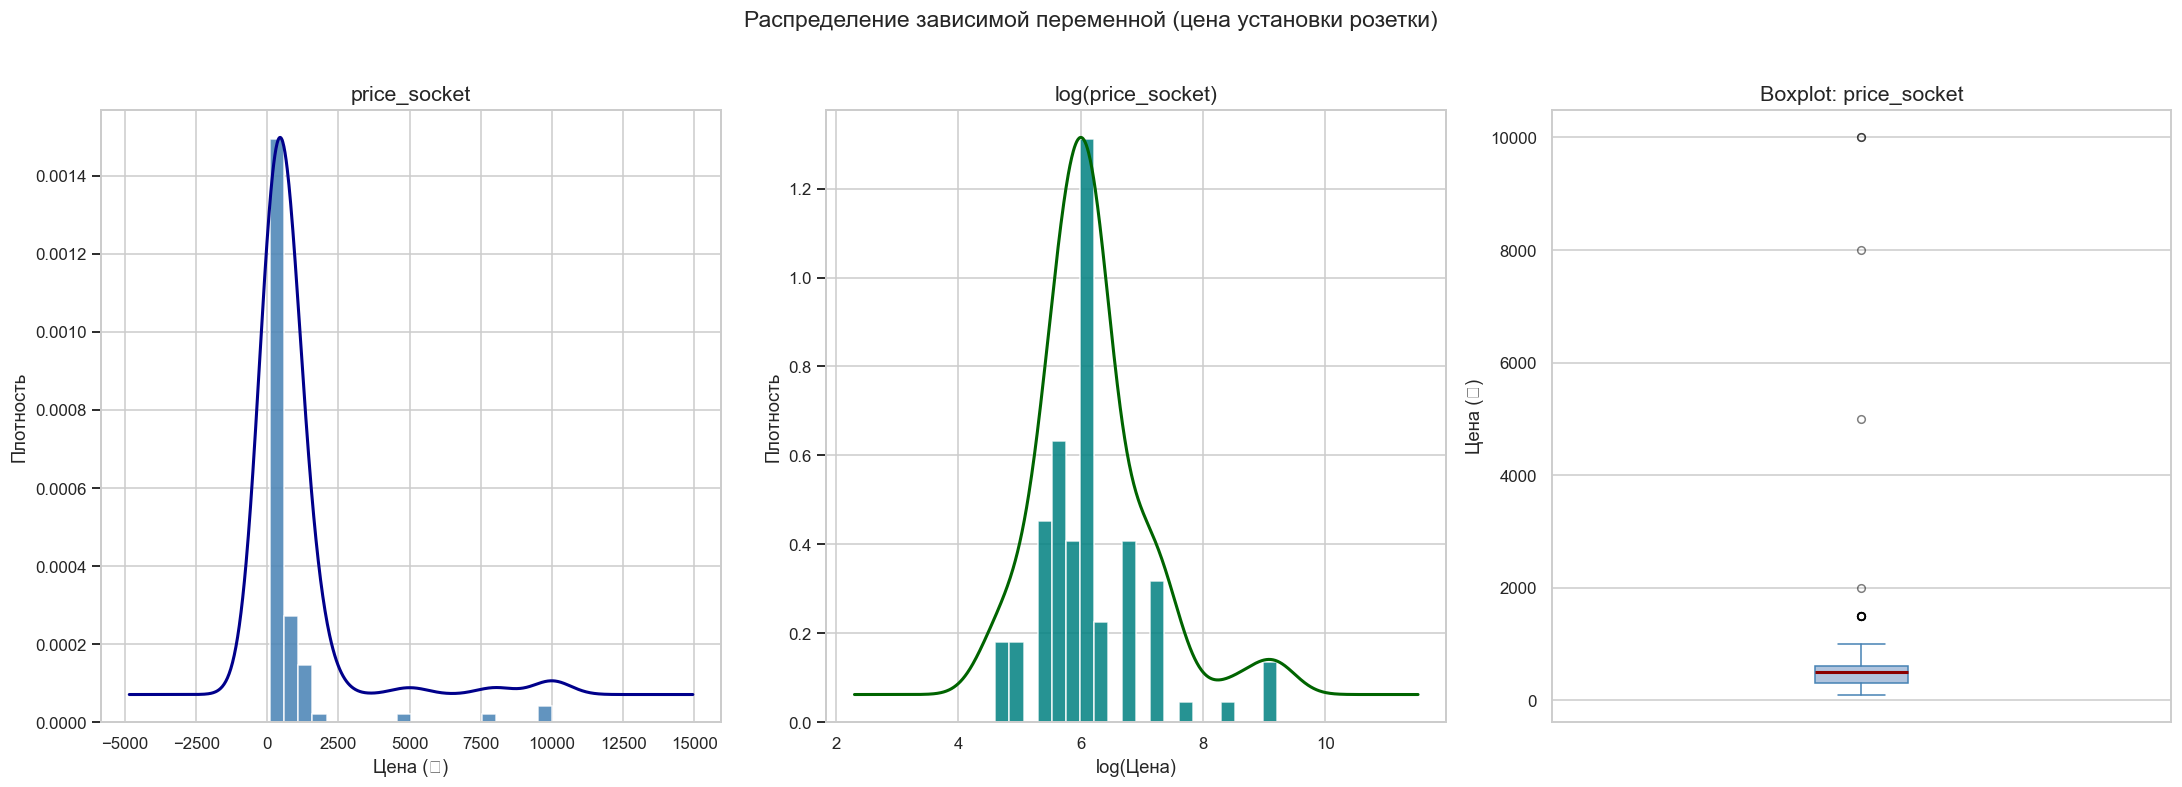

Медиана     : 500 ₽
Среднее     : 852 ₽
Асимметрия  : 4.680  (level)
Асимметрия  : 1.272  (log)

Вывод: log-трансформация рекомендуется


In [44]:
prices = df['price_socket'].dropna()
log_prices = np.log(prices)

fig, axes = plt.subplots(1, 3, figsize=(20, 7))

# Гистограмма + KDE
axes[0].hist(prices, bins=20, color='steelblue', edgecolor='white', alpha=0.85, density=True)
ax0b = axes[0].twinx()
prices.plot.kde(ax=ax0b, color='darkblue', linewidth=2)
ax0b.set_yticks([])
ax0b.set_ylabel('')
axes[0].set_title('price_socket', fontsize=14)
axes[0].set_xlabel('Цена (₽)', fontsize=12)
axes[0].set_ylabel('Плотность', fontsize=12)
axes[0].tick_params(labelsize=11)

# log(price_socket)
axes[1].hist(log_prices, bins=20, color='teal', edgecolor='white', alpha=0.85, density=True)
ax1b = axes[1].twinx()
log_prices.plot.kde(ax=ax1b, color='darkgreen', linewidth=2)
ax1b.set_yticks([])
ax1b.set_ylabel('')
axes[1].set_title('log(price_socket)', fontsize=14)
axes[1].set_xlabel('log(Цена)', fontsize=12)
axes[1].set_ylabel('Плотность', fontsize=12)
axes[1].tick_params(labelsize=11)

# Boxplot
axes[2].boxplot(
    prices, vert=True, patch_artist=True,
    boxprops=dict(facecolor='lightsteelblue', color='steelblue'),
    medianprops=dict(color='darkred', linewidth=2),
    whiskerprops=dict(color='steelblue'),
    capprops=dict(color='steelblue'),
    flierprops=dict(marker='o', color='steelblue', alpha=0.5, markersize=5)
)
axes[2].set_title('Boxplot: price_socket', fontsize=14)
axes[2].set_ylabel('Цена (₽)', fontsize=12)
axes[2].set_xticks([])
axes[2].tick_params(labelsize=11)

plt.suptitle('Распределение зависимой переменной (цена установки розетки)', fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

print(f"Медиана     : {prices.median():.0f} ₽")
print(f"Среднее     : {prices.mean():.0f} ₽")
print(f"Асимметрия  : {prices.skew():.3f}  (level)")
print(f"Асимметрия  : {log_prices.skew():.3f}  (log)")
print(f"\nВывод: {'log-трансформация рекомендуется' if abs(log_prices.skew()) < abs(prices.skew()) else 'log не улучшает симметрию'}")

### 5. Распределения непрерывных регрессоров

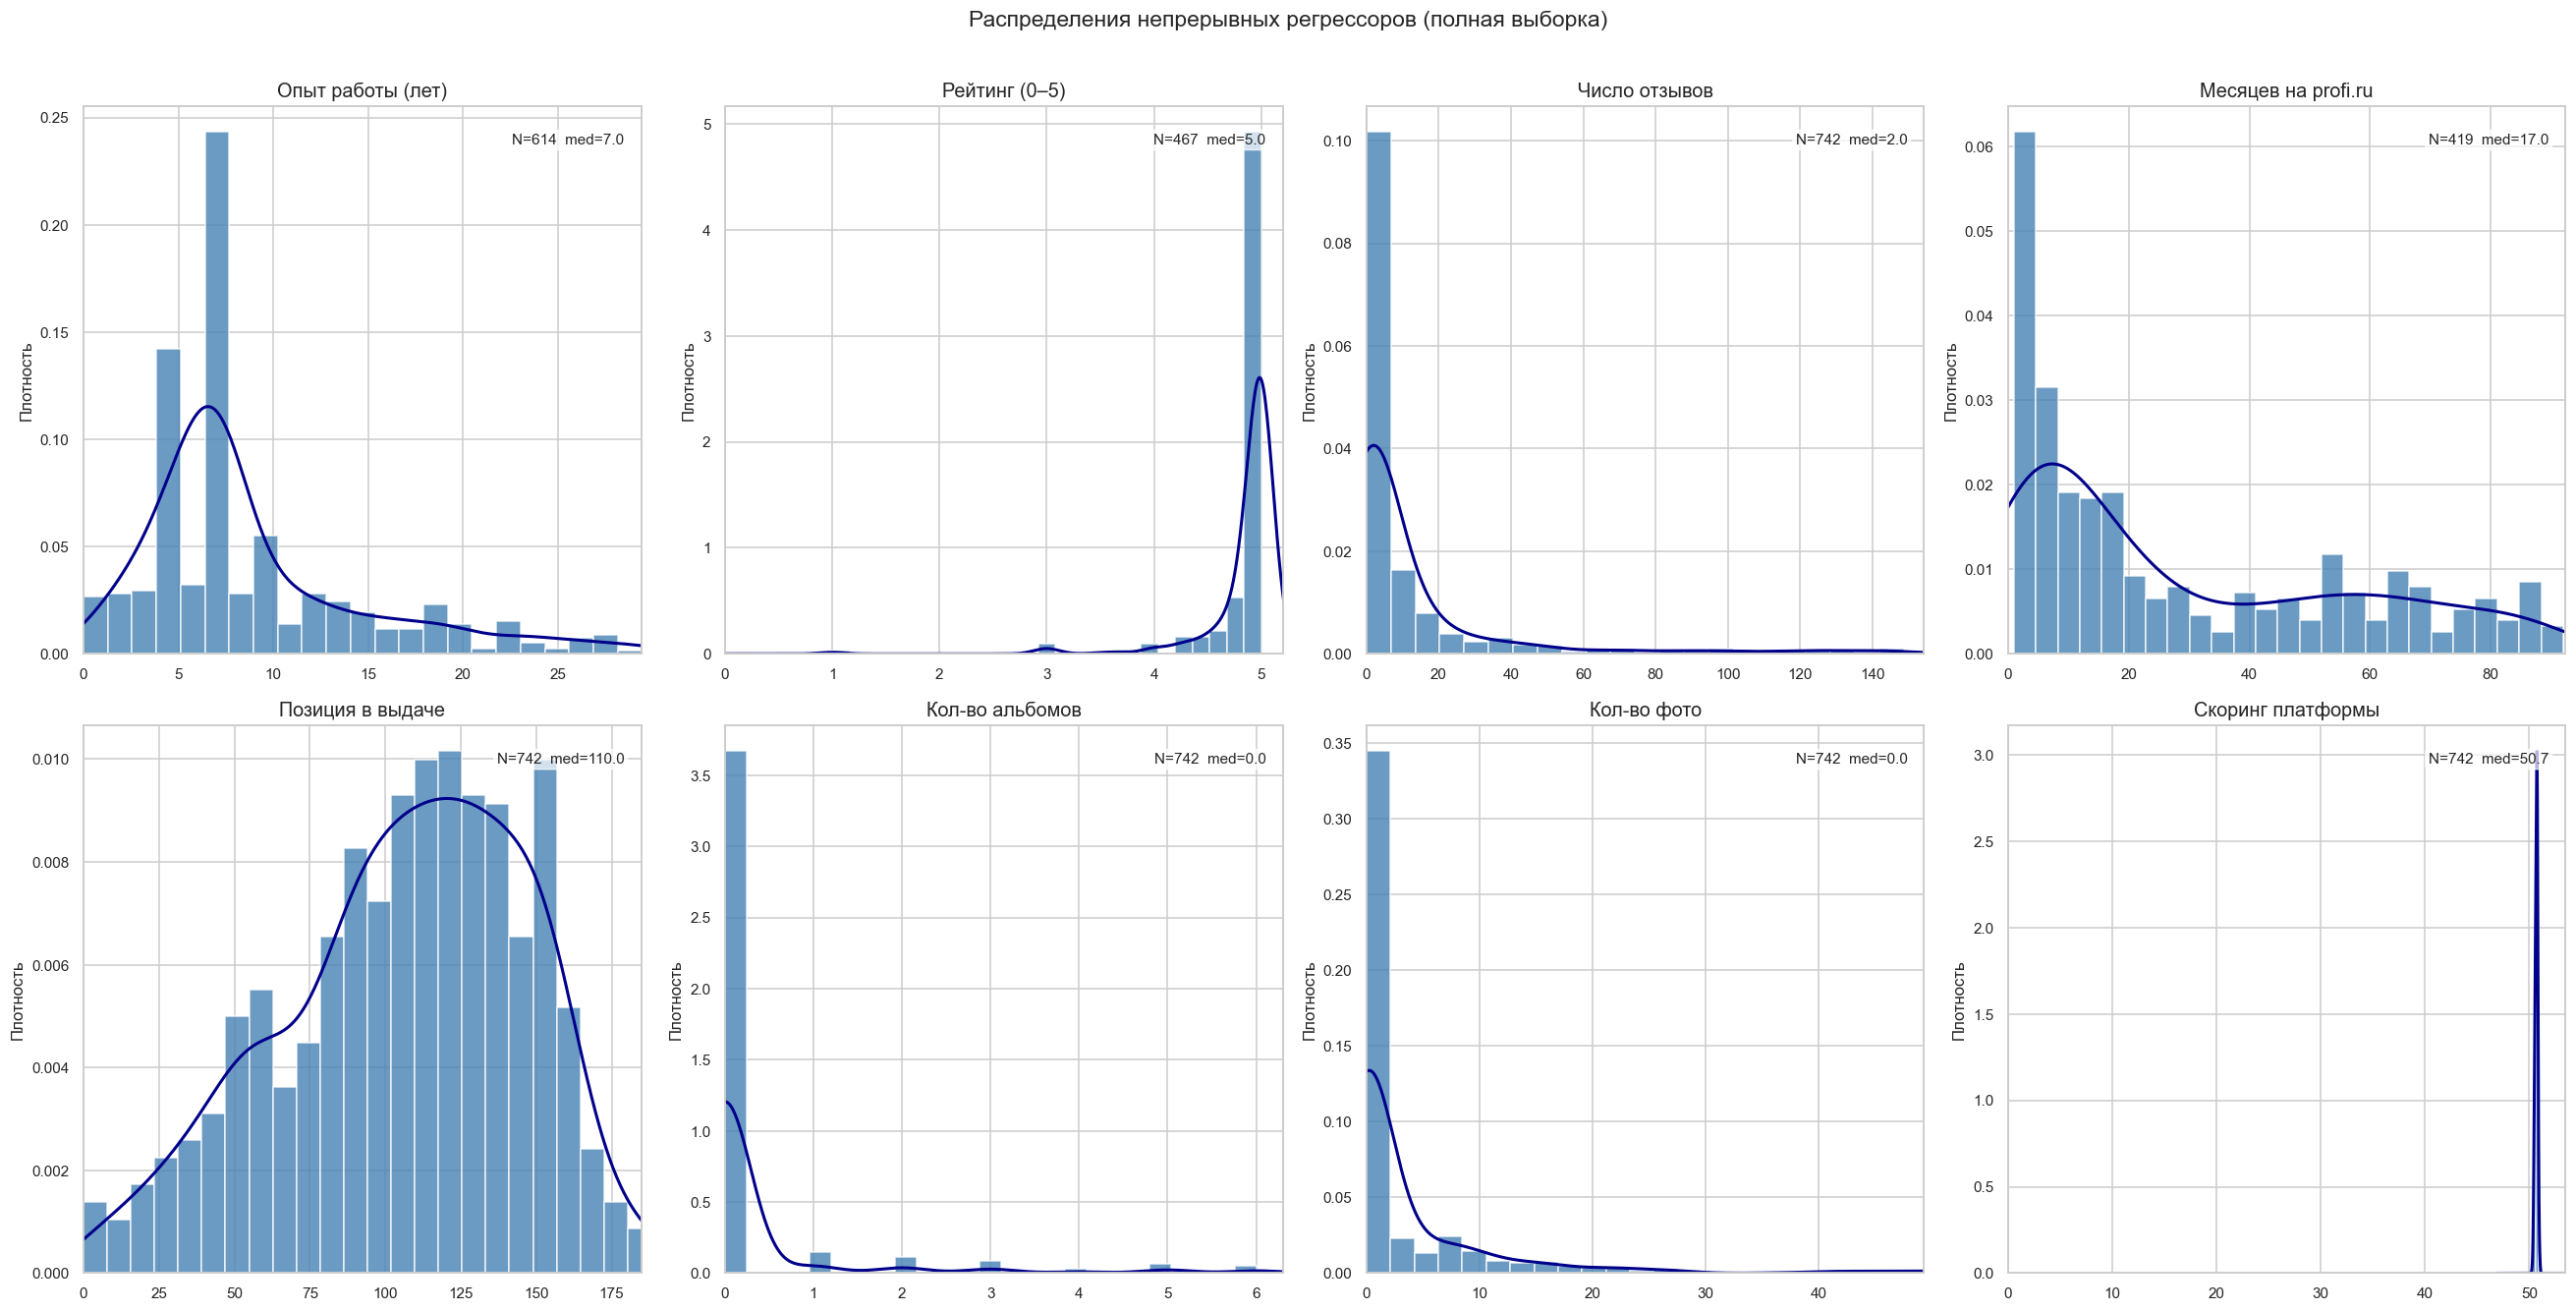

Примечание: rating=NaN означает отсутствие рейтинга (нет отзывов).
Для остальных переменных ось X ограничена 98-м процентилем (редкие выбросы скрыты для читаемости).


In [45]:
cont_vars = {
    'work_experience'  : 'Опыт работы (лет)',
    'rating'           : 'Рейтинг (0–5)',
    'reviews_count'    : 'Число отзывов',
    'months_on_profi_ru': 'Месяцев на profi.ru',
    'rang_id'          : 'Позиция в выдаче',
    'album_count'      : 'Кол-во альбомов',
    'photos_count'     : 'Кол-во фото',
    'cur_score'        : 'Скоринг платформы',
}

# Явные ограничения оси X: для рейтинга — шкала 0–5;
# для остальных (строго ≥ 0) — от 0 до 98-го процентиля, чтобы редкие выбросы не сжимали столбцы
xlim_fixed = {
    'rating': (0, 5.2),
}

fig, axes = plt.subplots(2, 4, figsize=(24, 12))
axes = axes.flatten()

for i, (col, label) in enumerate(cont_vars.items()):
    data = df[col].dropna()

    if col in xlim_fixed:
        xlo, xhi = xlim_fixed[col]
    else:
        xlo = 0
        xhi = data.quantile(0.98) * 1.05

    data_plot = data[(data >= xlo) & (data <= xhi * 1.1)]

    axes[i].hist(data_plot, bins=25, color='steelblue', edgecolor='white', alpha=0.80, density=True)
    try:
        data_plot.plot.kde(ax=axes[i], color='darkblue', linewidth=2)
    except Exception:
        pass
    axes[i].set_xlim(xlo, xhi)
    axes[i].set_title(label, fontsize=13)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Плотность', fontsize=11)
    axes[i].tick_params(labelsize=10)
    axes[i].annotate(
        f'N={data.count()}  med={data.median():.1f}',
        xy=(0.97, 0.95), xycoords='axes fraction',
        ha='right', va='top', fontsize=10,
        bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=0.7)
    )

plt.suptitle('Распределения непрерывных регрессоров (полная выборка)', fontsize=15, y=1.01)
plt.tight_layout()
plt.show()

print("Примечание: rating=NaN означает отсутствие рейтинга (нет отзывов).")
print("Для остальных переменных ось X ограничена 98-м процентилем (редкие выбросы скрыты для читаемости).")

### 6. Категориальные и бинарные переменные

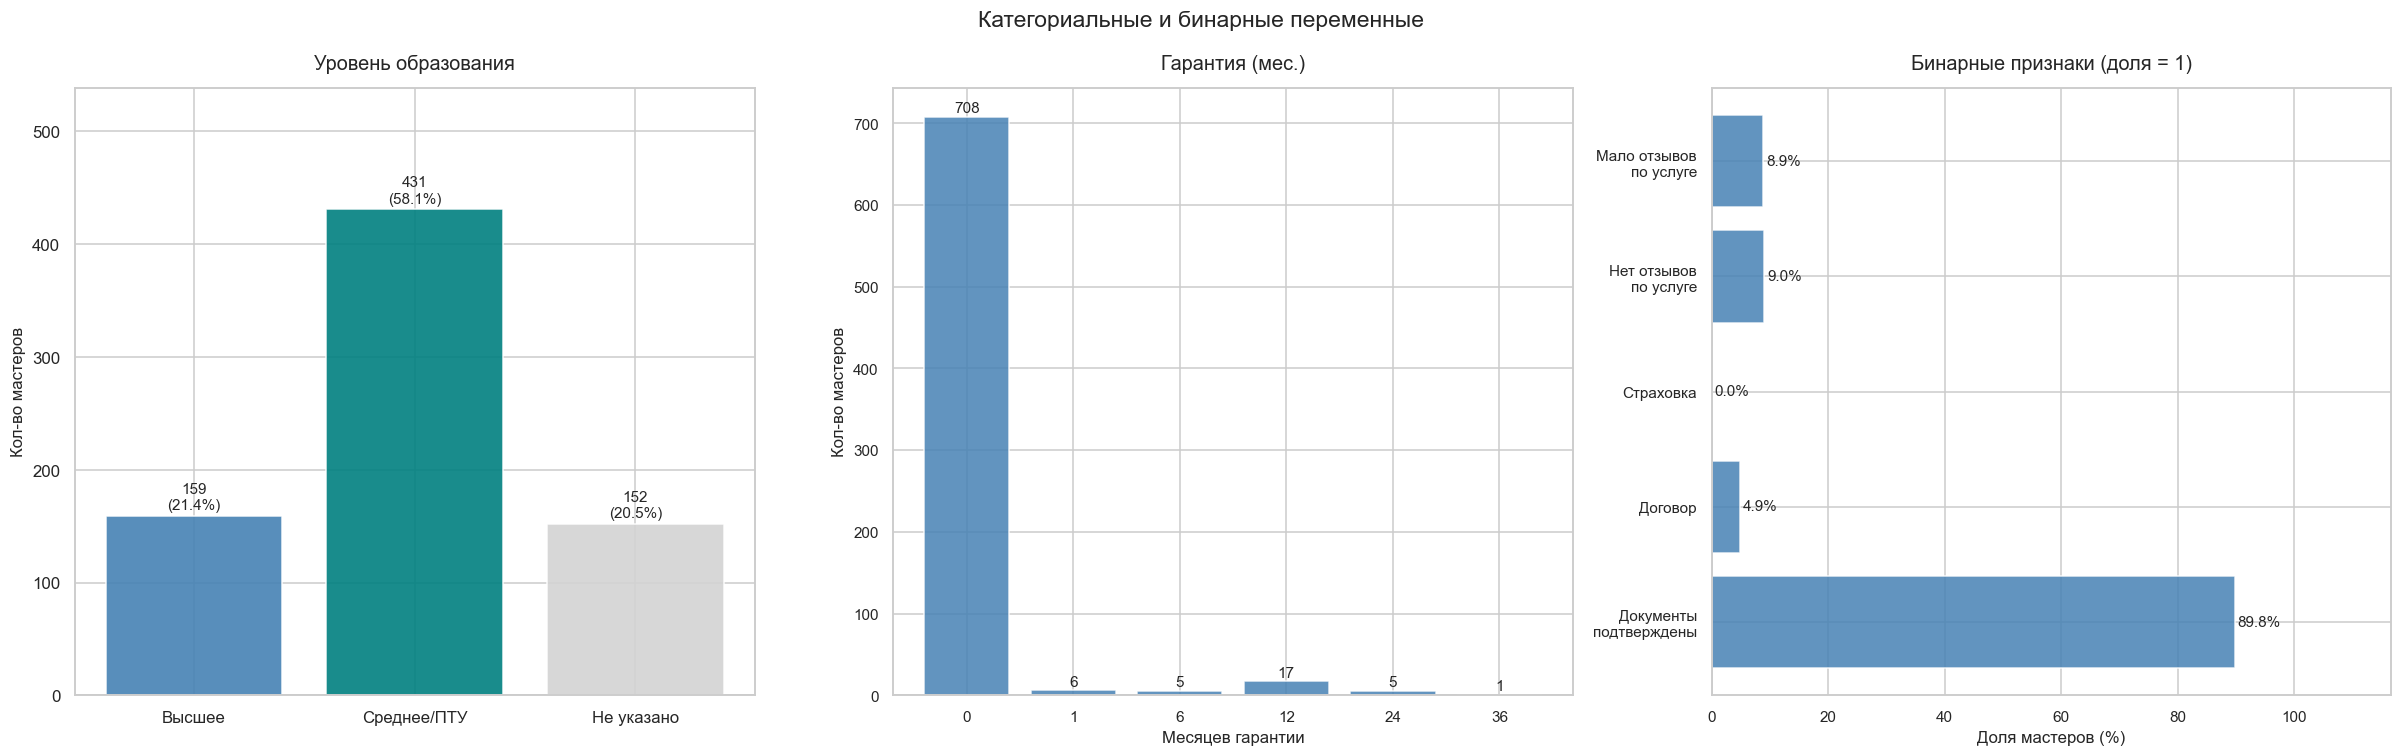

In [46]:
def edu_category(row):
    if row['has_higher_education'] == 1:
        return 'Высшее'
    elif row['has_secondary_education'] == 1:
        return 'Среднее/ПТУ'
    else:
        return 'Не указано'

edu_counts = df.apply(edu_category, axis=1).value_counts().reindex(['Высшее', 'Среднее/ПТУ', 'Не указано'])
edu_pcts = edu_counts / len(df) * 100

# ── Гарантия ──────────────────────────────────────────────────────────────
guarantee_counts = df['guarantee'].dropna().value_counts().sort_index()

fig, axes = plt.subplots(1, 3, figsize=(22, 7))

# Образование
colors_edu = ['steelblue', 'teal', 'lightgray']
bars_edu = axes[0].bar(edu_counts.index, edu_counts.values, color=colors_edu, edgecolor='white', alpha=0.9)
axes[0].set_title('Уровень образования', fontsize=13, pad=12)
axes[0].set_ylabel('Кол-во мастеров', fontsize=11)
axes[0].tick_params(axis='x', labelsize=11)
# Поднимаем верхнюю границу, чтобы подписи над столбцами не упирались в заголовок
axes[0].set_ylim(0, edu_counts.max() * 1.25)
for bar, pct in zip(bars_edu, edu_pcts):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2, bar.get_height() + 3,
        f'{bar.get_height():.0f}\n({pct:.1f}%)',
        ha='center', va='bottom', fontsize=10
    )

# Гарантия
axes[1].bar(guarantee_counts.index.astype(str), guarantee_counts.values,
            color='steelblue', edgecolor='white', alpha=0.85)
axes[1].set_title('Гарантия (мес.)', fontsize=13, pad=12)
axes[1].set_xlabel('Месяцев гарантии', fontsize=11)
axes[1].set_ylabel('Кол-во мастеров', fontsize=11)
axes[1].tick_params(labelsize=10)
for i, v in enumerate(guarantee_counts.values):
    axes[1].text(i, v + 2, str(v), ha='center', va='bottom', fontsize=10)

# Прочие бинарные
other_bin = ['docs_verified', 'has_contract', 'has_insurance',
             'no_electric_reviews', 'few_electric_reviews']
other_labels = ['Документы\nподтверждены', 'Договор', 'Страховка',
                'Нет отзывов\nпо услуге', 'Мало отзывов\nпо услуге']
shares = [df[c].mean() * 100 for c in other_bin]
bars_bin = axes[2].barh(other_labels, shares, color='steelblue', edgecolor='white', alpha=0.85)
axes[2].set_xlabel('Доля мастеров (%)', fontsize=11)
axes[2].set_title('Бинарные признаки (доля = 1)', fontsize=13, pad=12)
axes[2].set_xlim(0, max(shares) * 1.3)
axes[2].tick_params(labelsize=10)
for bar, v in zip(bars_bin, shares):
    axes[2].text(v + 0.5, bar.get_y() + bar.get_height() / 2,
                 f'{v:.1f}%', va='center', fontsize=10)

plt.suptitle('Категориальные и бинарные переменные', fontsize=15)
plt.tight_layout()
plt.show()

### 7. Selection-анализ: мастера с ценой vs без цены

In [47]:
from scipy.stats import ttest_ind

mask = df['price_socket'].notna()
priced   = df[mask]
unpriced = df[~mask]

print(f"С ценой: {mask.sum()} | Без цены: {(~mask).sum()}\n")

compare_cols = [
    ('work_experience',   'Опыт (лет)'),
    ('rating',            'Рейтинг'),
    ('reviews_count',     'Число отзывов'),
    ('months_on_profi_ru','Месяцев на profi.ru'),
    ('rang_id',           'Позиция в выдаче'),
    ('cur_score',         'Скоринг платформы'),
    ('album_count',       'Альбомов'),
    ('photos_count',      'Фото'),
    ('guarantee',         'Гарантия (мес.)'),
]

rows = []
for col, label in compare_cols:
    a = priced[col].dropna()
    b = unpriced[col].dropna()
    _, p = ttest_ind(a, b, equal_var=False)
    rows.append({
        'Признак'           : label,
        'Среднее (с ценой)' : round(a.mean(), 2),
        'Среднее (без цены)': round(b.mean(), 2),
        'Разница'           : round(a.mean() - b.mean(), 2),
        'p-value'           : round(p, 4),
        'Значимо (p<0.05)'  : '✓' if p < 0.05 else '',
    })

compare_df = pd.DataFrame(rows)
display(compare_df)

С ценой: 96 | Без цены: 646



,Признак,Среднее (с ценой),Среднее (без цены),Разница,p-value,Значимо (p<0.05)
0,Опыт (лет),10.78,8.83,1.94,0.0256,✓
1,Рейтинг,4.80,4.86,-0.06,0.2621,
2,Число отзывов,28.23,18.00,10.23,0.1503,
3,Месяцев на profi.ru,41.90,27.94,13.96,0.0370,✓
4,Позиция в выдаче,110.15,105.67,4.47,0.3130,
5,Скоринг платформы,51.05,50.79,0.27,0.3651,
6,Альбомов,0.76,0.52,0.24,0.2634,
7,Фото,8.93,3.84,5.08,0.0017,✓
8,Гарантия (мес.),1.83,0.34,1.49,0.0093,✓


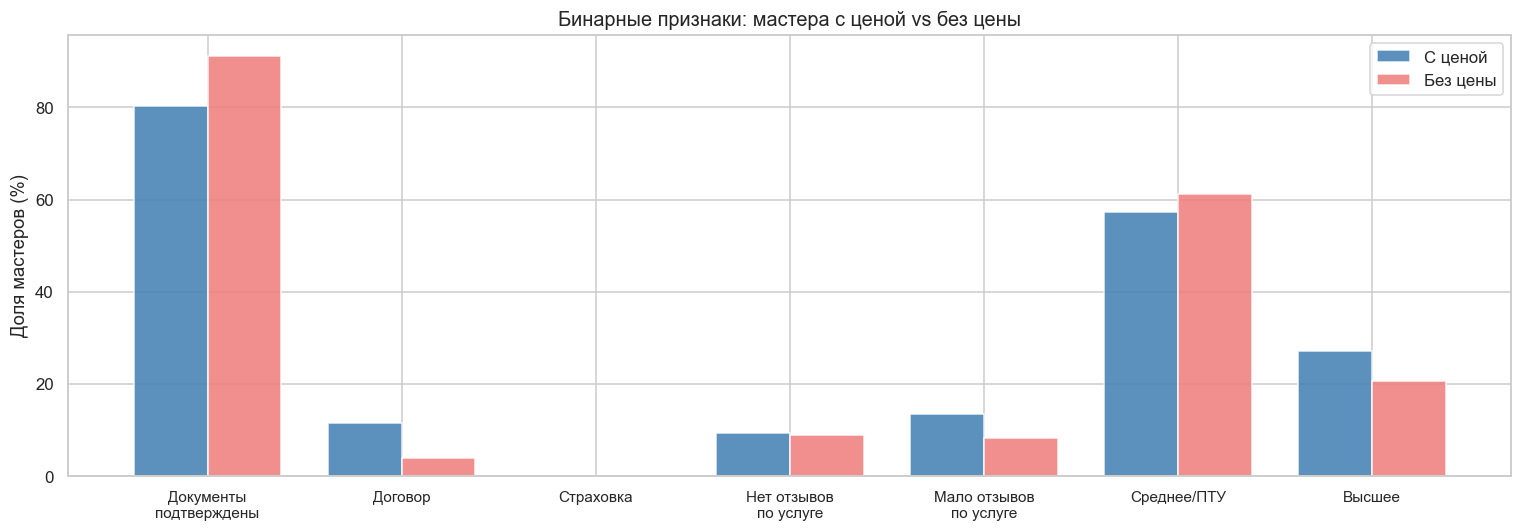

In [48]:
bin_sel_cols   = ['docs_verified', 'has_contract', 'has_insurance',
                  'no_electric_reviews', 'few_electric_reviews',
                  'has_secondary_education', 'has_higher_education']
bin_sel_labels = ['Документы\nподтверждены', 'Договор', 'Страховка',
                  'Нет отзывов\nпо услуге', 'Мало отзывов\nпо услуге',
                  'Среднее/ПТУ', 'Высшее']

x = np.arange(len(bin_sel_cols))
w = 0.38

fig, ax = plt.subplots(figsize=(14, 5))
bars1 = ax.bar(x - w/2, [priced[c].mean()*100   for c in bin_sel_cols], w,
               label='С ценой', color='steelblue', alpha=0.88, edgecolor='white')
bars2 = ax.bar(x + w/2, [unpriced[c].mean()*100 for c in bin_sel_cols], w,
               label='Без цены', color='lightcoral', alpha=0.88, edgecolor='white')
ax.set_xticks(x)
ax.set_xticklabels(bin_sel_labels, fontsize=10)
ax.set_ylabel('Доля мастеров (%)')
ax.set_title('Бинарные признаки: мастера с ценой vs без цены', fontsize=13)
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

### 8. Корреляционный анализ

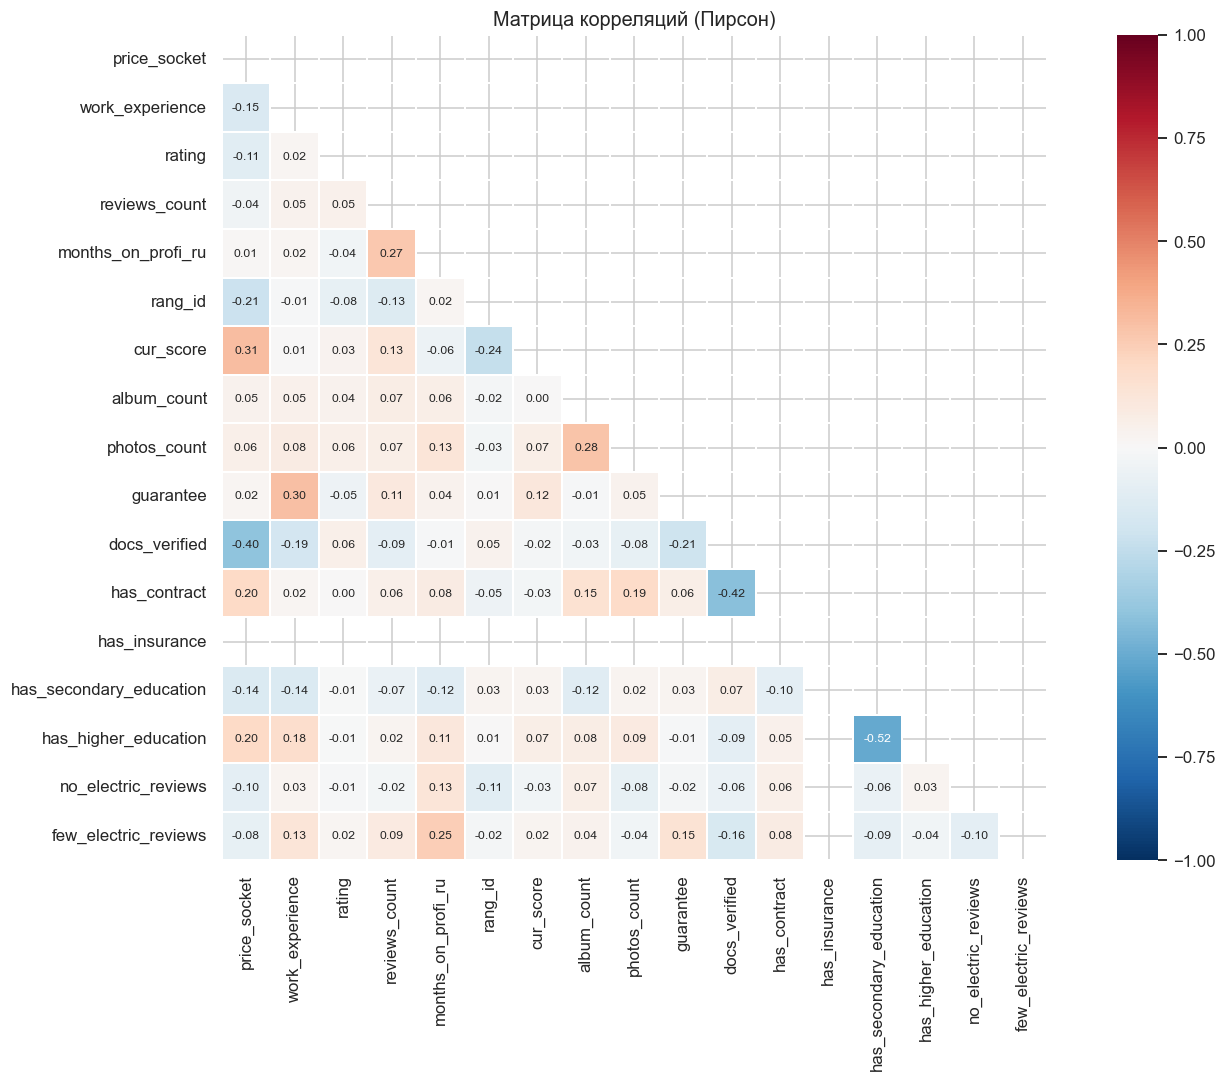

Корреляции с price_socket (по убыванию |r|):
docs_verified             -0.404409
cur_score                  0.305546
rang_id                   -0.214314
has_higher_education       0.201135
has_contract               0.200614
work_experience           -0.150891
has_secondary_education   -0.144402
rating                    -0.113898
no_electric_reviews       -0.097216
few_electric_reviews      -0.083896
photos_count               0.061230
album_count                0.046524
reviews_count             -0.044910
guarantee                  0.017557
months_on_profi_ru         0.010073
has_insurance                   NaN


In [49]:
corr_cols = [
    'price_socket', 'work_experience', 'rating', 'reviews_count',
    'months_on_profi_ru', 'rang_id', 'cur_score', 'album_count',
    'photos_count', 'guarantee', 'docs_verified', 'has_contract',
    'has_insurance', 'has_secondary_education', 'has_higher_education',
    'no_electric_reviews', 'few_electric_reviews',
]

corr = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(14, 10))
mask_upper = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr, mask=mask_upper, ax=ax,
    annot=True, fmt='.2f', annot_kws={'size': 8},
    cmap='RdBu_r', center=0, vmin=-1, vmax=1,
    linewidths=0.3, square=True
)
ax.set_title('Матрица корреляций (Пирсон)', fontsize=13)
plt.tight_layout()
plt.show()

# Топ корреляций с price_socket
price_corr = corr['price_socket'].drop('price_socket').sort_values(key=abs, ascending=False)
print("Корреляции с price_socket (по убыванию |r|):")
print(price_corr.to_string())

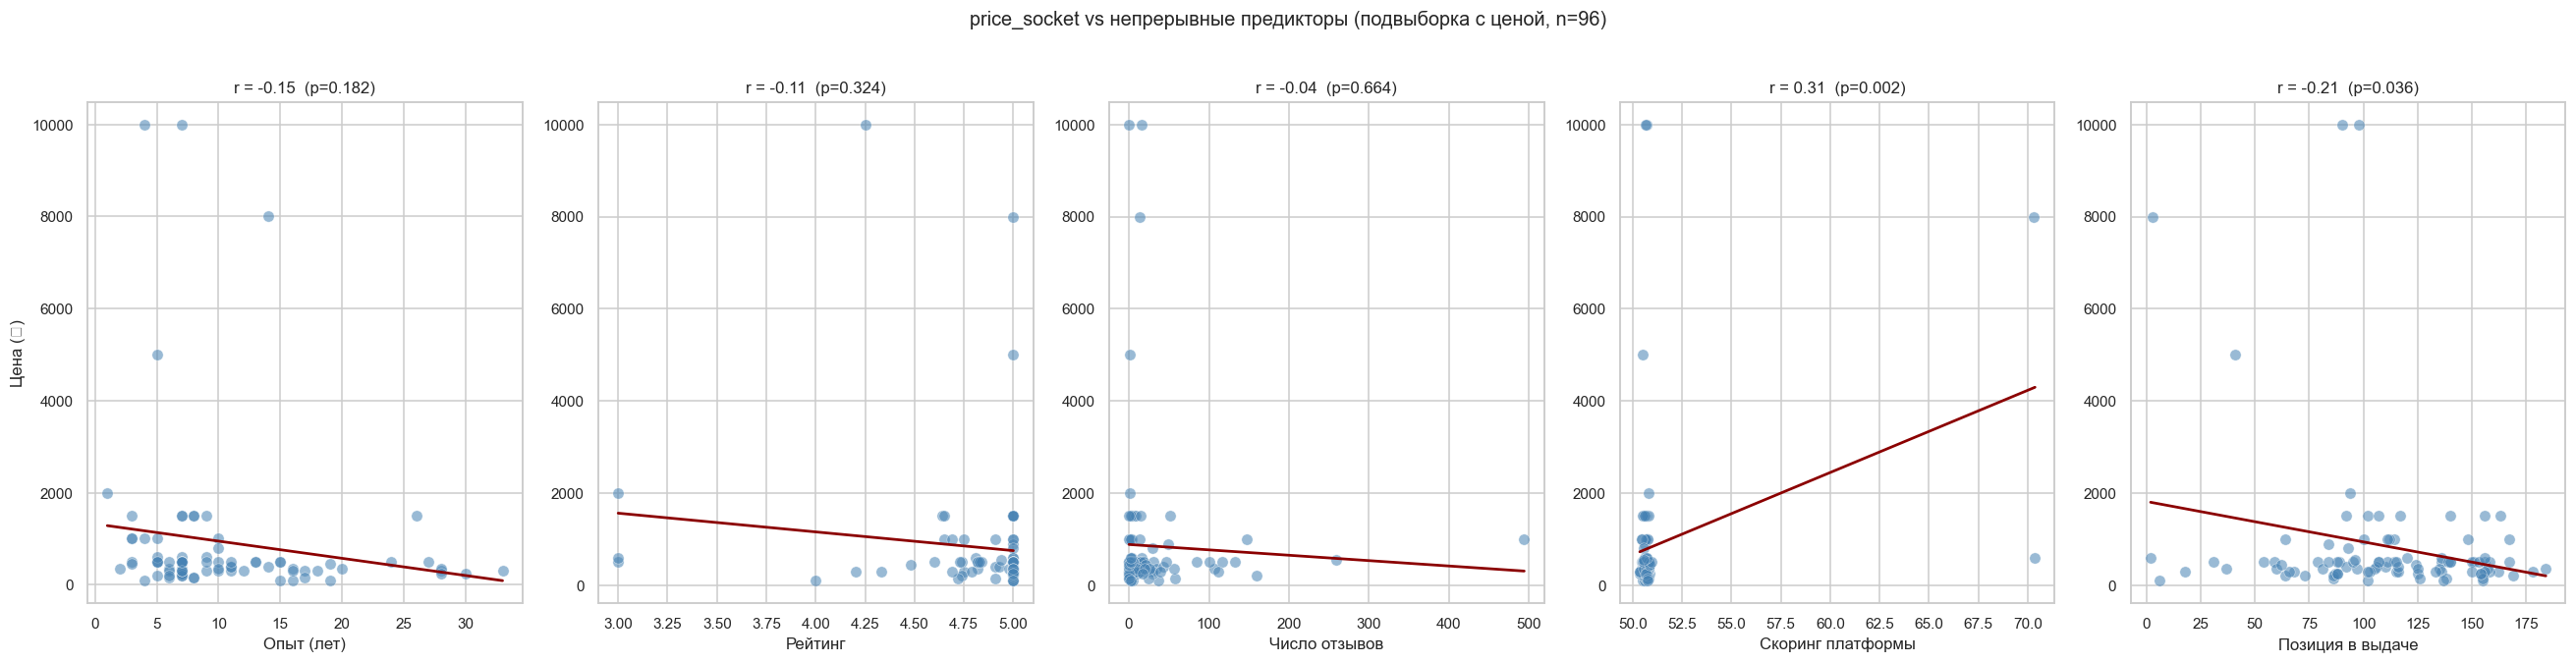

In [50]:
scatter_vars = [
    ('work_experience',   'Опыт (лет)'),
    ('rating',            'Рейтинг'),
    ('reviews_count',     'Число отзывов'),
    ('cur_score',         'Скоринг платформы'),
    ('rang_id',           'Позиция в выдаче'),
]

fig, axes = plt.subplots(1, 5, figsize=(24, 6))

for i, (col, label) in enumerate(scatter_vars):
    sub = df[df['price_socket'].notna() & df[col].notna()]
    x_data = sub[col].values
    y_data = sub['price_socket'].values

    axes[i].scatter(x_data, y_data, alpha=0.55, s=55, color='steelblue', edgecolors='white', linewidths=0.4)

    slope, intercept, r_val, p_val, _ = stats.linregress(x_data, y_data)
    x_line = np.linspace(x_data.min(), x_data.max(), 80)
    axes[i].plot(x_line, slope * x_line + intercept, color='darkred', linewidth=1.8)

    axes[i].set_xlabel(label, fontsize=11)
    axes[i].set_ylabel('Цена (₽)' if i == 0 else '', fontsize=11)
    axes[i].set_title(f'r = {r_val:.2f}  (p={p_val:.3f})', fontsize=11)
    axes[i].tick_params(labelsize=10)

n_sub = df['price_socket'].notna().sum()
plt.suptitle(f'price_socket vs непрерывные предикторы (подвыборка с ценой, n={n_sub})', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

### 9. Итоговые выводы EDA

**Данные и пропуски**
- Выборка: 743 мастера Казани, у 96 (~13%) указана цена установки розетки
- Пропуск `price_socket` означает, что мастер **не добавил замену розетки в прайс** (не специализируется на этой услуге или принимает заявки только по запросу) — это не отказ от раскрытия цены
- `discount` пропущен структурно вместе с `price_socket`
- `work_experience` (128 NaN) и `months_on_profi_ru` (324 NaN) потребуют решения: исключение строк или импутация медианой

---

**Зависимая переменная**
- `price_socket` имеет выраженную правостороннюю асимметрию → **log-трансформация рекомендуется** для регрессии (симметрия log-распределения лучше)
- Явный выброс (50 000 ₽) удалён как вероятная ошибка ввода — в 37 раз выше медианы

---

**Основание для модели Хекмана**
- Мастера с ценой и без неё **систематически различаются** по ключевым признакам (t-test значим): у первых выше рейтинг, больше отзывов, чаще есть договор и страховка, лучше позиция в выдаче
- Пропуск цены — **не случайный**: решение добавить услугу в прайс коррелирует с характеристиками мастера → OLS только по подвыборке с ценой даст смещённые оценки → необходима двухшаговая модель Хекмана

---

**Кандидаты в exclusion restriction** *(влияют на решение добавить услугу в прайс, но не на саму цену работы)*

- `no_electric_reviews` / `few_electric_reviews` — мастер без отзывов по электрике скорее всего не специализируется на ней и потому не добавляет розетку в прайс; при этом наличие или отсутствие отзывов по смежным услугам не должно напрямую определять рыночную стоимость самой работы


---

**Ожидаемые знаки коэффициентов (уравнение цены)**


| Признак | Ожидаемый знак | Обоснование |
|---|:---:|---|
| `work_experience` | **+** | Опытные мастера берут дороже |
| `rating` | **+** | Высокий рейтинг → ценовая премия |
| `reviews_count` | **+** | Репутация снижает неопределённость → выше цена |
| `guarantee` | **+** | Гарантия = дополнительная ценность услуги |
| `has_contract` | **+** | Легальное оформление → дороже |
| `has_higher_education` | **+** | Хотя неоднозначно для физического труда |
| `cur_score` | **+** | Внутренний скоринг платформы — знак уточняется по корреляции |

---

**Потенциальные проблемы**
- Малая подвыборка с ценой (~96): осторожность с числом регрессоров (правило большого пальца: ≤ 9–10 переменных)
- Мультиколлинеарность: `reviews_count` и `rating` — вероятно, скоррелированы; `album_count` и `photos_count` — тоже. Проверить VIF
- `cur_score` варьируется в узком диапазоне — проверить при включении в модель